# `alignEpsilon` 收敛曲线测试

这个 Notebook 用来测试并可视化 `BaseAgent.alignEpsilon` 的收敛行为。

- 你可以在“参数设置”单元里手动改参数后重跑出图。
- 如果环境安装了 `ipywidgets`，还可以用滑条实时调参。

In [4]:
import math
import numpy as np
import matplotlib.pyplot as plt


def align_epsilon(step, max_eps=1.0, min_eps=0.05, decay_rate=2000, lam=1.0, power=2):
    """与 BaseAgent.alignEpsilon 一致的公式（去掉 sat/env 依赖）"""
    return min_eps + (max_eps - min_eps) * math.exp(-lam * step / (decay_rate * (power ** 2)))


def get_epsilon_curve(steps=5000, max_eps=1.0, min_eps=0.05, decay_rate=2000, lam=1.0, power=2):
    x = np.arange(steps + 1)
    y = np.array([align_epsilon(s, max_eps, min_eps, decay_rate, lam, power) for s in x])
    return x, y


def plot_curve(steps=5000, max_eps=1.0, min_eps=0.05, decay_rate=2000, lam=1.0, power=2):
    x, y = get_epsilon_curve(steps, max_eps, min_eps, decay_rate, lam, power)

    plt.figure(figsize=(9, 5))
    plt.plot(x, y, linewidth=2, label='epsilon(step)')
    plt.axhline(min_eps, linestyle='--', linewidth=1, label=f'min_eps={min_eps}')
    plt.title('Convergence Curve of alignEpsilon')
    plt.xlabel('step')
    plt.ylabel('epsilon')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f'epsilon(0)={y[0]:.6f}, epsilon({steps})={y[-1]:.6f}')
    print(f'delta={y[0] - y[-1]:.6f}')

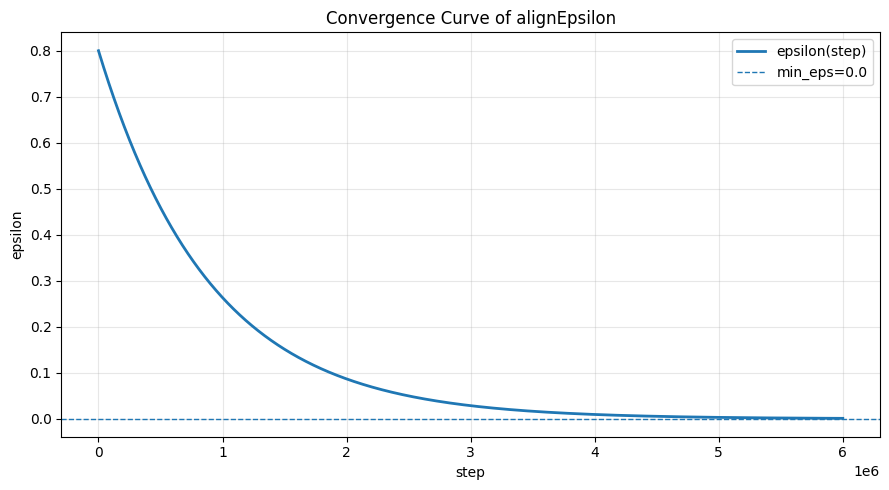

epsilon(0)=0.800000, epsilon(6000000)=0.001018
delta=0.798982


In [6]:
# 参数设置（手动修改这里即可）
steps = 6000000
max_eps = 0.8
min_eps = 0.00
decay_rate = 50
lam = 0.0005
power = 3

plot_curve(
    steps=steps,
    max_eps=max_eps,
    min_eps=min_eps,
    decay_rate=decay_rate,
    lam=lam,
    power=power,
)